In [38]:
import geopandas as gpd
import os
import glob
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import seaborn as sns
from osgeo import gdal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.dates as md
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec
from scipy.stats import ttest_ind
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import cmocean
import colorsys
pd.set_option('mode.chained_assignment', None)

def create_drought_dekads(drought_months,year):
    """
    Create a list of dekads (10-day periods) for the given drought months and year.
    """
    drought_dekads = []
    for i in range(len(drought_months)):
        for day in ['01','11','21']:
            drought_dekads.append(f'{year}-{drought_months[i]}-{day}')
    return drought_dekads

def get_xlims(data,type):
    """Get x-axis limits for different types of plots based on the provided data."""

    fig, ax = plt.subplots(1,3,figsize=(15, 15))
    if type == 'plot':
        ax[0].plot(data.values,md.date2num(data.index.values))
        xlims = ax[0].get_xlim()
        plt.close()
        return xlims
        
    elif type == 'barh1':
        ax[2].barh(md.date2num(data.date.values),data.num)
        xlims = ax[2].get_xlim()
        plt.close()
        return xlims
        
    elif type == 'barh2':
        NDVIA_mean, SWIA_mean = data
        ax[1].barh(md.date2num(NDVIA_mean.dek.values)+2,NDVIA_mean['NDVIA'])
        ax[1].barh(md.date2num(SWIA_mean.dek.values)-2,SWIA_mean['SWIA'])
        xlims = ax[1].get_xlim()
        plt.close()
        return xlims

def create_rect(transplant_dates, harvest_dates, pan_list, flo_list, x_lims, i, labels):
    """Create rectangles for different growth stages based on the provided dates and limits."""
    rect_t = Rectangle((x_lims[0],md.date2num(transplant_dates)[i]),
                       x_lims[1] - x_lims[0],
                       pan_list[i] - md.date2num(transplant_dates)[i],
                       color='green',label="Tillering" if labels and (i==0) else '_nolabel_',alpha=0.3)
    rect_p = Rectangle((x_lims[0],pan_list[i]),
                       x_lims[1] - x_lims[0],
                       flo_list[i] - pan_list[i],
                       color='grey',label="Panicle Initiation" if labels and (i==0) else '_nolabel_',alpha=0.3)
    rect_f = Rectangle((x_lims[0],flo_list[i]),
                       x_lims[1] - x_lims[0],
                       md.date2num(harvest_dates)[i] - flo_list[i],
                       color='orange',label="Maturity" if labels and (i==0) else '_nolabel_',alpha=0.3)
    return rect_t, rect_p, rect_f

def draw_heatmaps(count_files_list):

    fig, ax =plt.subplots(2,5,figsize=(30,12), sharex=True,sharey=True)
    cbar_ax = fig.add_axes([.91, .53, .01, .42])
    cbar_ax2 = fig.add_axes([.91, .1, .01, .42])
    i=0
    j=0
    for file in count_files_list:
        df = pd.read_csv(file,sep=';').drop(columns=['Unnamed: 0']).set_index('zones')

        if j==0:
            vmin=10
            vmax=275
            sns.heatmap(df, ax=ax[j][i], cbar=i==0, vmin=vmin, vmax=vmax, label = 'VICI count', cmap='Reds', cbar_ax=None if i else cbar_ax)
            ax[j][i].set_title(file.split('/')[-1].split(']')[0].replace('[',''),size=24)
            ax[j][i].tick_params(axis='both', which='major', labelsize=24, labelrotation=360)
            if i == 0:
                ax[j][i].tick_params(axis="x", length=0, labelbottom=False, )
            else:
                ax[j][i].tick_params(axis="both", length=0, labelbottom=False, labelleft=False)
        if j==1:
            vmin=100
            vmax=425
            sns.heatmap(df, ax=ax[j][i],cbar=i==0,vmin=vmin,vmax=vmax,label = 'SWIA count',cmap='Reds',cbar_ax=None if i else cbar_ax2)
            
            if i > 0:
                ax[j][i].tick_params(axis="y", length=0, labelleft=False)
            ax[j][i].tick_params(axis='both', which='major', labelsize=24, labelrotation=360)

        ax[j][i].set_ylabel('')
        ax[j][i].set_xlabel('')
        if i == 4:
            i = 0
            j += 1
        else:
            i+=1
    cbar_ax.tick_params(labelsize=24) 

    cbar_ax2.tick_params(labelsize=24) 
    fig.supylabel('Number of zones (NDVIA-determined)',x=0.001,y=0.5,fontsize=28)
    fig.supxlabel('Threshold values',x=0.5,y=0.001,fontsize=28)
    fig.tight_layout(rect=[0, 0, .9, 1])
    plt.show()

def draw_improvement_heatmaps(imp_files_list):
    fig, ax =plt.subplots(4,5,figsize=(30,24), sharex=True,sharey=True)

    cmap_used = cmocean.cm.balance_r

    cbar_ax = fig.add_axes([.91, .12, .01, .8])
    i=0
    j=0
    vmin=-0.2
    vmax=0.2
    for file in imp_files_list:
        
        df = pd.read_csv(file,sep=',').set_index('zones')
        if j==0:

            sns.heatmap(df, ax=ax[j][i],cbar=i==0,vmin=vmin,vmax=vmax,label = 'VICI',cmap=cmap_used,cbar_ax=None if i else cbar_ax)
            ax[j][i].set_title(file.split('/')[-1].split('_')[0],size=28)
            ax[j][i].tick_params(axis='both', which='major', labelsize=24, labelrotation=360)
            if i == 0:
                ax[j][i].tick_params(axis="x", length=0, labelbottom=False, )
            else:
                ax[j][i].tick_params(axis="both", length=0, labelbottom=False, labelleft=False)
        if j==1:

            sns.heatmap(df, ax=ax[j][i],cbar=i==0,vmin=vmin,vmax=vmax,label = 'SWIA',cmap=cmap_used,cbar_ax=None if i else cbar_ax)
            
            if i > 0:
                ax[j][i].tick_params(axis="y", length=0, labelleft=False)
            ax[j][i].tick_params(axis='both', which='major', labelsize=24, labelrotation=360)
        if j==2:

            sns.heatmap(df, ax=ax[j][i],cbar=i==0,vmin=vmin,vmax=vmax,label = 'both',cmap=cmap_used,cbar_ax=None if i else cbar_ax)
            if i > 0:
                ax[j][i].tick_params(axis="y", length=0, labelleft=False)
            ax[j][i].tick_params(axis='both', which='major', labelsize=24, labelrotation=360)
        if j == 3:
            sns.heatmap(df, ax=ax[j][i],cbar=i==0,vmin=vmin,vmax=vmax,label = 'only SWIA + NDVIA',cmap=cmap_used,cbar_ax=None if i else cbar_ax)
            if i > 0:
                ax[j][i].tick_params(axis="y", length=0, labelleft=False)
            ax[j][i].tick_params(axis='both', which='major', labelsize=24, labelrotation=360)

        ax[j][i].set_ylabel('')
        ax[j][i].set_xlabel('')

        if i == 4:
            i = 0
            j += 1
        else:
            i+=1

    cbar_ax.tick_params(labelsize=24) 

    fig.supylabel('Number of zones (NDVIA-determined)',x=0.001,y=0.5,fontsize=28)
    fig.supxlabel('Threshold values',x=0.5,y=0.001,fontsize=28)
    fig.tight_layout(rect=[0, 0, .9, 1])
    plt.show()

def read_and_reorganise(cube_file,harmonics_file, wc_file):
    """ Read and reorganize the data from the provided cube, harmonics, and WorldCover cropland class files."""
    wc = rasterio.open(wc_file).read(1)
    dataset = gdal.Open(cube_file)
    
    harmonics_cube = rasterio.open(harmonics_file).read()
    harmonics_cube[np.where(harmonics_cube==0)]=np.nan
    for band in range(harmonics_cube.shape[0]):
        harmonics_cube[band,:,:] = np.interp(harmonics_cube[band], (np.nanmin(harmonics_cube[band]), np.nanmax(harmonics_cube[band])), (-1, +1))
    harmonics_cube = np.nan_to_num(harmonics_cube, nan=0)
    harmonics_transposed = np.transpose(harmonics_cube,(1,2,0))
    bands = []
    for i in range(dataset.RasterCount):
        band = dataset.GetRasterBand(i + 1)
        bands.append(band.ReadAsArray())
    bands_2d = np.dstack(bands)
    bands_combined = np.concatenate((bands_2d, harmonics_transposed), axis=2) 
    bands_2 = bands_combined.copy()
    data_wc = bands_2[wc!=2]
    data_df = pd.DataFrame(data_wc)
    data_df.fillna(-9999)
    data_df = data_df.loc[(data_df!=-9999).all(axis=1)]
    cut_nodata = np.where(data_df==-9999,0,data_df)
    return cut_nodata

def calculate_rmse(mse_files_list, mse_p_files_list):
    rmse_vals = {}
    rmse_df = pd.DataFrame(columns=['2020','2021','2022','2023','2024'])
    for file in mse_files_list:
        df_mse = pd.read_csv(file,sep=';').drop(columns=['Unnamed: 0']).set_index('zones')
        rmse_vals[f'{file.split("/")[-3]}_{file.split("_")[2]}'] = [np.sqrt(np.mean(df_mse.values))]
        rmse_df.at[file.split('_')[2][:-4],file.split('_')[2][-4:]] = np.mean(np.sqrt(df_mse.values))
    for file in mse_p_files_list:
        df_mse = pd.read_csv(file,sep=';').drop(columns=['Unnamed: 0']).set_index('zones')
        rmse_vals[f'{file.split("/")[-3]}_{file.split("_")[2]}'] = [np.sqrt(np.mean(df_mse.values))]
    return rmse_vals, rmse_df

def draw_rmse_barplot(rmse_vals):
    rmse_df = pd.DataFrame(rmse_vals).T.reset_index()
    rmse_df.rename(columns={'index':'names',0:'RMSE'}, inplace=True)
    rmse_df['names_split']= rmse_df['names'].str.split('_')
    rmse_df['Variable Name']= rmse_df['names_split'].apply(lambda x: f'{x[1][:-4]} ({x[0]})')
    rmse_df['Variable Name'] = rmse_df['Variable Name'].apply(lambda x: f'{x[:4]}/{x[4:]}' if 'SWIANDVIA' in x else x)
    rmse_df['Variable Name'] = rmse_df['Variable Name'].apply(lambda x: f'{x.replace("both","combined")}' if 'both' in x else x)
    rmse_df['year']= rmse_df['names'].str[-4:]
    rmse_df.drop(columns=['names','names_split'], inplace=True)

    # Match same base variable across seasonal and phenological categories
    rmse_df['Base Variable'] = rmse_df['Variable Name'].str.replace(r'\s*\(.*\)$', '', regex=True)
    rmse_df['Category'] = rmse_df['Variable Name'].str.extract(r'\((.*)\)$')[0].str.strip()
    base_vars = rmse_df['Base Variable'].unique()
    palette_base = dict(zip(base_vars, sns.color_palette('rocket', len(base_vars))))


    full_palette = {}
    for name, base, category in zip(rmse_df['Variable Name'], rmse_df['Base Variable'], rmse_df['Category']):
        color = palette_base[base]
        if isinstance(category, str) and category.lower() == 'phenological':
            color = greenify(color)
        full_palette[name] = color

    g = sns.catplot(
        data=rmse_df,
        x='year',
        y='RMSE',
        hue='Variable Name',
        kind='bar',
        height=5,
        aspect=2,
        palette=full_palette,
    )

    sns.move_legend(g, "upper center", title='Variable Name', frameon=True)

def greenify(color):
    h, l, s = colorsys.rgb_to_hls(*color)
    return colorsys.hls_to_rgb(1/3, l, s)

def extract_data_for_graphs(rice_plots, main_dir, num_zones, u_thresh, state):
    spindices = pd.read_csv(os.path.join(main_dir,'shapefiles','rice_plots_spi_spei_data.csv'))
    spindices['year'] = spindices.apply(lambda x: x['time'][:4],axis=1)
    spindices['date'] = spindices.apply(lambda x: x['time'][:10],axis=1)
    
    years_list = ['2020','2021','2022','2023','2024']

    NDVIA_path = os.path.join(main_dir, 'Output','analysis',f'{num_zones}zones',f'analysis_05_{u_thresh}','VICI')
    SWIA_path = os.path.join(main_dir, 'Output','analysis_swia',f'{num_zones}zones',f'analysis_05_{u_thresh}','SWIA')
    NDVIA_files = sorted([file for file in glob.glob(os.path.join(NDVIA_path,'*')) if file[-14:-10] in years_list])
    SWIA_files = sorted([file for file in glob.glob(os.path.join(SWIA_path,'*')) if file[-14:-10] in years_list])

    plots = rice_plots.copy()

    for year in years_list:
        plots = plots.drop(plots.loc[plots[f'?INC{year}'] == 'NIL'].index)

    print('Filtering plot data by state.')
    plots_state = plots[plots['STATE']==state]
    plots_state = plots_state[plots_state[f'YREXP_{str(year)[2:]}'].notnull()]
        
    state_ids = list(plots_state.id)
    filter_year = spindices[spindices.year.isin(years_list)]
    filter_state = filter_year[filter_year.id.isin(state_ids)]
        
    df_filtered = filter_state[[col for col in filter_state.columns if any(x in col for x in ['SPI', 'SPEI', 'date'])]]
    spi_spei_cols = [col for col in df_filtered.columns if 'date' not in col]
    grouped = df_filtered.groupby('date')[spi_spei_cols].agg(['mean', 'std'])

    print('Extracting index values per plot location.')

    drought_df = pd.DataFrame()
    for year in years_list:
        year_calc_df = pd.DataFrame()
        for i, row in plots_state.iterrows():
            if row[f'YREXP_{str(year)[2:]}'] is None:
                continue
            drought_months = row[f'YREXP_{str(year)[2:]}'].split('/')
            
            drought_months = [months_dict[m] for m in drought_months]
            drought_dekads = create_drought_dekads(drought_months,year)
    
            year_calc_df = pd.concat([year_calc_df,
                                    pd.DataFrame({d:[1] for d in drought_dekads})])
            
        drought_df = pd.concat([drought_df,
                                pd.DataFrame(year_calc_df.sum()).reset_index().rename(columns={'index':'date',0:'num'}).sort_values(by='date').reset_index(drop=True)])

    print('Extracting anomaly values per plot location.')
    NDVIA_pos = pd.DataFrame()
    SWIA_pos = pd.DataFrame()
    for i, row in plots_state.reset_index(drop=True).iterrows():
        
        tp = months_dict[row['RCvty1TRP'].split('/')[0]]
        ht = months_dict[row['RCvty1HVT'].split('/')[-1]]
        if i == 0:
            prev_tp = tp
            prev_ht = ht
        else:
            if int(tp) < int(prev_tp):
                prev_tp = tp
            if int(ht) > int(prev_ht):
                prev_ht = ht
                
        for dek in NDVIA_files:
            with rasterio.open(dek)as src:
                val = [x for x in src.sample([(row.geometry.centroid.x,row.geometry.centroid.y)])][0][0]
                if val > 0:
                    NDVIA_pos = pd.concat([NDVIA_pos,pd.DataFrame({'dek':[dek.split('/')[-1][5:-4]],'NDVIA':[val]})])
        for dek in SWIA_files:
            with rasterio.open(dek)as src:
                val = [x for x in src.sample([(row.geometry.centroid.x,row.geometry.centroid.y)])][0][0]
                if val > 0:
                    SWIA_pos = pd.concat([SWIA_pos,pd.DataFrame({'dek':[dek.split('/')[-1][5:-4]],'SWIA':[val]})])
    
    NDVIA_mean = NDVIA_pos.groupby('dek').mean().reset_index()
    SWIA_mean = SWIA_pos.groupby('dek').mean().reset_index()
    
    mean_ht = months_dict[plots_state['RCvty1HVT'].unique()[0]]
    
    transplant_dates = [f'{y}-{prev_tp}-01' for y in years_list]
    harvest_dates = [f'{y}-{mean_ht}-01' for y in years_list]

    print('Getting seasonal dates for state.')
    pan_dict = {}
    flo_dict = {}
    month_pos = pd.DataFrame()
    for y in years_list:
        pan_stage = pd.DataFrame()
        flo_stage = pd.DataFrame()
        for i, row in plots_state.iterrows():
            tp = months_dict[row['RCvty1TRP'].split('/')[0]]
            ht = months_dict[row['RCvty1HVT'].split('/')[-1]]
            pan_stage = pd.concat([pan_stage,pd.DataFrame({'dek':
                                                           md.date2num([create_drought_dekads([tp],y)[0]])+60})])
            flo_stage = pd.concat([flo_stage,pd.DataFrame({'dek':
                                                           md.date2num([create_drought_dekads([tp],y)[0]])+90})])
            
            for i in range(int(tp),int(ht)):
                temp_m = pd.DataFrame({'year':y,'dek':create_drought_dekads([f'{i:02d}'],y)})
                month_pos = pd.concat([month_pos,temp_m])
        
        pan_dict[y] = pan_stage['dek'].value_counts().index.tolist()[0]
        flo_dict[y] = flo_stage['dek'].value_counts().index.tolist()[0]
        
    return plots_state, years_list, grouped, transplant_dates, harvest_dates, pan_dict, flo_dict, NDVIA_mean, SWIA_mean, drought_df

def draw_state_figs(state, plots_state, years_list, grouped, transplant_dates, harvest_dates, pan_dict, flo_dict, NDVIA_mean, SWIA_mean, drought_df):

    fig = plt.figure(figsize=(15,15))
    gs = gridspec.GridSpec(5, 4)
    gs1 = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec = gs[:,:3])
    gs2 = gridspec.GridSpecFromSubplotSpec(15, 2, subplot_spec = gs[:,3],height_ratios=[0.025,0.15,0.025]*5,width_ratios=[0.02,0.98])#,hspace=1.5)
    ax = [fig.add_subplot(cell) for cell in gs1]
    ax2 = [fig.add_subplot(cell) for cell in gs2]
    i=3
    i_list = []
    plot_cols = ['SPI3','SPEI3']
    
    for y in years_list:
        yield_all = plots_state[[f'{y} t/h' for y in years_list]]
        for z in years_list:
            yield_all[f'{z} t/h'] = yield_all[f'{z} t/h'][yield_all[f'{z} t/h'].lt(yield_all[f'{z} t/h'].quantile(0.95))]
    
        yield_all = yield_all.stack().groupby(level=0).mean().to_frame().rename(columns={0:'mean yield'})
        yield_state = plots_state[f'{y} t/h'][plots_state[f'{y} t/h'].lt(plots_state[f'{y} t/h'].quantile(0.95))]
        if y == '2024':
            yield_change = plots_state[f'change{y}'][plots_state[f'change{y}'].between(plots_state[f'change{y}'].quantile(0.05),plots_state[f'change{y}'].quantile(0.95))]
        else:
            yield_change = plots_state[f'change{y}'][plots_state[f'change{y}'].between(plots_state[f'change{y}'].quantile(0.05),plots_state[f'change{y}'].quantile(0.95))]
        ttest_stat = ttest_ind(yield_state, yield_all['mean yield'],equal_var=False)
    
        ax2[i].boxplot([yield_state,yield_all['mean yield'],yield_change],tick_labels=[f'{y} \nyield','mean \nyield','yield \nchange'])
        ax2[i].spines["left"].set_visible(False)
        ax2[i].spines["bottom"].set_visible(False)
        ax2[i].spines["top"].set_visible(False)
        ax2[i].yaxis.tick_right()
        ax2[i].yaxis.set_label_position("right")
        ax2[i].set_ylabel('yield (t/h)')
        ax2[i].set_ylim(np.round(np.min([0,yield_change.min()])-1),
                                 np.round(np.max([yield_state.max(),yield_all['mean yield'].max()])+1))
        
        if ttest_stat.pvalue < 0.05:
            ax2[i].text(0.95,yield_state.max()+1,'a')
            ax2[i].text(1.95,yield_all['mean yield'].max()+1,'b')
        else:
            ax2[i].text(0.95,yield_state.max()+1,'a')
            ax2[i].text(1.95,yield_all['mean yield'].max()+1,'a')
        i_list.append(i)
        i+=6
        
    for n in [n for n in range(30) if n not in i_list ]:
        ax2[n].axis('off')
    ax_lims = md.date2num(grouped[plot_cols[0]]['mean'].index.values)
    
    ### Plot graph 1
    x_lims = get_xlims(grouped['SPI3']['mean'],'plot')
    for i in range(len(transplant_dates)):
        rect_t, rect_p, rect_f = create_rect(transplant_dates, harvest_dates, list(pan_dict.values()), list(flo_dict.values()), x_lims, i, labels=False)
        ax[0].add_patch(rect_t)
        ax[0].add_patch(rect_p)
        ax[0].add_patch(rect_f)
        
    ax[0].plot([0]* len(grouped['SPI3']['mean'].values),md.date2num(grouped['SPI3'].index.values),color='grey',linestyle='--',alpha=0.5)
    
    for col in plot_cols:
        mean = grouped[col]['mean']
        std = grouped[col]['std']
        
        # Plot line for mean
        ax[0].plot(mean.values, md.date2num(mean.index.values), label=col)
        
    ax[0].set_ylabel('Date')
    ax[0].set_xlabel('mean SPI/SPEI value')
    
    ### Plot graph 2
    
    x_lims = get_xlims([NDVIA_mean,SWIA_mean],'barh2')
    for i in range(len(transplant_dates)):
        rect_t, rect_p, rect_f = create_rect(transplant_dates, harvest_dates, list(pan_dict.values()), list(flo_dict.values()), x_lims, i, labels = False)
        ax[1].add_patch(rect_t)
        ax[1].add_patch(rect_p)
        ax[1].add_patch(rect_f)
        
    ax[1].barh(md.date2num(NDVIA_mean.dek.values)+2,NDVIA_mean['NDVIA'],height=11,label='mean NDVIA',color='red', alpha=0.5)
    ax[1].barh(md.date2num(SWIA_mean.dek.values)-2,SWIA_mean['SWIA'],height=11,label='mean SWIA', color='green', alpha=0.5)
    ax[1].tick_params(axis="y", which='major', length=0, labelleft=False, labelright=False)
    ax[1].tick_params(axis="y", which='minor', length=0, labelleft=False, labelright=False)
    ax[1].set_xlabel('mean NDVIA/SWIA value')
    
    ### Plot graph 3
    x_lims = get_xlims(drought_df,'barh1')
    for i in range(len(transplant_dates)):
        rect_t, rect_p, rect_f = create_rect(transplant_dates, harvest_dates, list(pan_dict.values()), list(flo_dict.values()), x_lims, i, labels = True)
        ax[2].add_patch(rect_t)
        ax[2].add_patch(rect_p)
        ax[2].add_patch(rect_f)
        
    ax[2].barh(md.date2num(drought_df.date.values),drought_df.num,height=11,label='num droughts', color='blue', alpha = 0.5)
    ax[2].tick_params(axis="y", which='major', length=0, labelleft=False, labelright=True)
    ax[2].tick_params(axis="y", which='minor', length=0, labelleft=False, labelright=True)
    ax[2].set_xlabel('number of reported drought dekads')
    
    for idx, a in enumerate(ax):
        for tick in a.yaxis.get_major_ticks():
            tick.set_pad(7 * tick.get_pad())
        a.yaxis.set_major_locator(md.YearLocator())
        a.yaxis.set_major_formatter(md.DateFormatter("%Y"))
        a.tick_params(which='major', axis='x', pad=20)
        a.yaxis.set_minor_locator(md.MonthLocator(interval=2))
        a.yaxis.set_minor_formatter(md.DateFormatter("%b"))
        a.set_ylim(ax_lims[-1],ax_lims[0])
        a.spines["top"].set_visible(False)
        
        if idx == 0:
            a.spines["right"].set_visible(False)
        if idx == 1:
            a.spines["left"].set_visible(False)
            a.spines["right"].set_visible(False)
        if idx == 2:
            a.spines["left"].set_visible(False)
        
    fig.legend(loc='upper center',ncols=10)
    fig.suptitle(f'{state.capitalize()} state summary',fontsize=24)

# Visualise results of MOFODRONI project

This notebook visualises the main results of the MOFODRONI project. Most of the data required is available in the folders uploaded in the git repository. However, the large datasets (particularly the NDVIA/SWIA datasets and stack files found in the _analysis_, *analysis_swia* and *stacks* folders, respectively) need to be downloaded from the Zenodo repository for this project. 

Zenodo datasets can be found at: https://zenodo.org/records/19593937

In [ ]:
months_dict = {'MAR':'03',
               'APR':'04',
               'MAY':'05',
               'JUN':'06',
               'JUL':'07',
               'SEP':'09',
               'AUG':'08',
               'OCT':'10',
               'NOV':'11',
               'DEC':'12',
               'NIL':'NIL'
              }
main_dir = Path(os.getcwd()).parent

rice_plots = gpd.read_file(os.path.join(main_dir,'shapefiles','field_data','RICE_PLOTS_POLYGONS_RF1_fix.shp'))

print('Imported plots.')

Imported plots.


In [ ]:
spindices = pd.read_csv('/home/eoafrica/shared/MOFODRONI/shapefiles/rice_plots_spi_spei_data.csv')
spindices.drop(columns = spindices.columns[list(spindices.columns).index('id')+1:],inplace=True)
spindices['dt'] = spindices.apply(lambda x: x['time'].split(' ')[0],axis=1)
spindices.drop(columns = ['time','lat','lon'], inplace=True)
spindices

## Zonal analysis

Here we analyze the distribution of NDVI pixel values over the study area. This analysis shows us that there are not clear clusters or zones that can be easily identified - rather pixel values are on a gradient that is much more challenging to cluster.

In [9]:
cube_file = os.path.join(main_dir,'Output','stacks','cube_to_cluster.img')
harmonics_file = os.path.join(main_dir,'Output','stacks','harmonics_cube.tif')
wc_file = os.path.join(main_dir,'Output','landcover','WorldCover_merged.tif')

cluster_input = read_and_reorganise(cube_file,harmonics_file, wc_file)


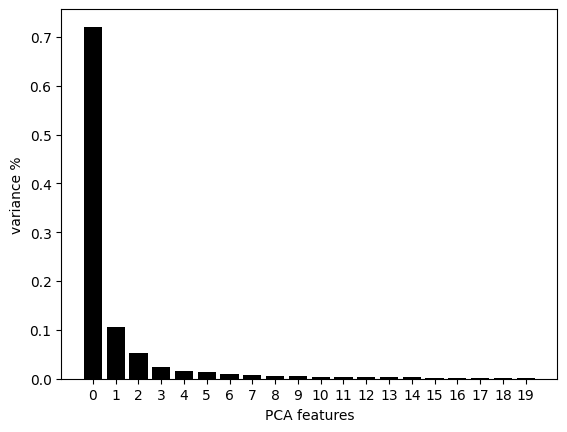

In [10]:
### PCA 
batch_size=10000
X_std = StandardScaler().fit_transform(cluster_input)
pca = PCA(n_components=20)
principalComponents = pca.fit_transform(X_std)# Plot the explained variances
features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_ratio_, color='black')
plt.xlabel('PCA features')
plt.ylabel('variance %')
plt.xticks(features)# Save components to a DataFrame
PCA_components = pd.DataFrame(principalComponents)

In [11]:
ks = range(2, 100)
inertias = []
sil=[]
X = PCA_components.iloc[:,:4]
X_sample = X.sample(10000).reset_index(drop=True)
for k in ks:
    # Create a KMeans instance with k clusters: model
    if k%10 == 0:
        print(f'Finished {k} clusters')
    model = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=1000, max_no_improvement=100, random_state=42, reassignment_ratio=0)
    
    # Fit model to samples
    model.fit(X)
    cluster_labels = model.fit_predict(X_sample)
    silhouette_avg = silhouette_score(X_sample, cluster_labels)
    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)
    sil.append(silhouette_avg)


Finished 10 clusters
Finished 20 clusters
Finished 30 clusters
Finished 40 clusters
Finished 50 clusters
Finished 60 clusters
Finished 70 clusters
Finished 80 clusters
Finished 90 clusters


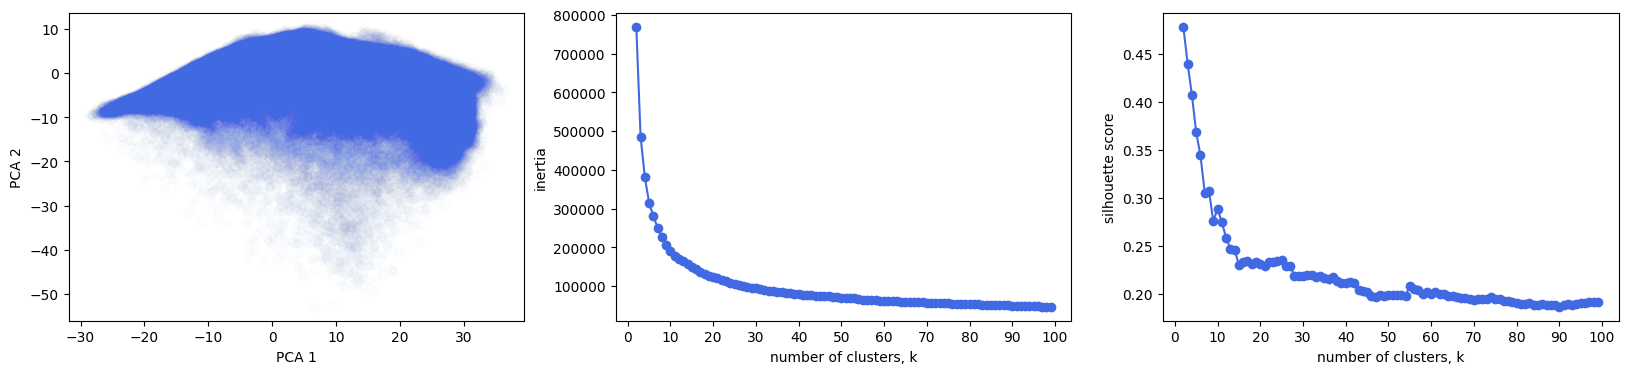

In [ ]:
fig,ax = plt.subplots(1,3,figsize=(20,4))
ax[0].scatter(PCA_components[0], PCA_components[1], alpha=.01, color='royalblue')
ax[0].set_xlabel('PCA 1')
ax[0].set_ylabel('PCA 2')
ax[1].plot(ks, inertias, '-o', color='royalblue')
ax[1].set_xlabel('number of clusters, k')
ax[1].set_ylabel('inertia')
ax[1].set_xticks(range(0,110,10))
ax[2].plot(ks, sil, '-o', color='royalblue')
ax[2].set_xlabel('number of clusters, k')
ax[2].set_ylabel('silhouette score')
ax[2].set_xticks(range(0,110,10))
plt.show()

## Anomaly variable analysis

Anomaly variable counts, adjusted R² scores, RMSE and model p-values were extracted as additional _.csv_ files when processing multivariate regression models. CSV files were generated through model comparison code found in _run_comparison.py_. They are accessible in the **model_analysis** folder, and we will visualise the results here.

#### Non-zero anomaly value counts

The first visualisation will show us the number of non-zero NDVIA and SWIA anomaly values over the entire growing season for different combinations of zone numbers and upper threshold values. These counts are calculated for pixels covering the locations of farmer plots collected during fieldwork.

In [14]:
csv_dir = os.path.join(main_dir,'Output','model_analysis')

counts_NDVIA = os.path.join(csv_dir,'count','VICI')
counts_SWIA = os.path.join(csv_dir,'count','SWIA')
count_files_list = [os.path.join(counts_NDVIA, file) for file in os.listdir(counts_NDVIA)] + [os.path.join(counts_SWIA, file) for file in os.listdir(counts_SWIA)]

/tmp/ipykernel_1702298/3109537169.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, .9, 1])


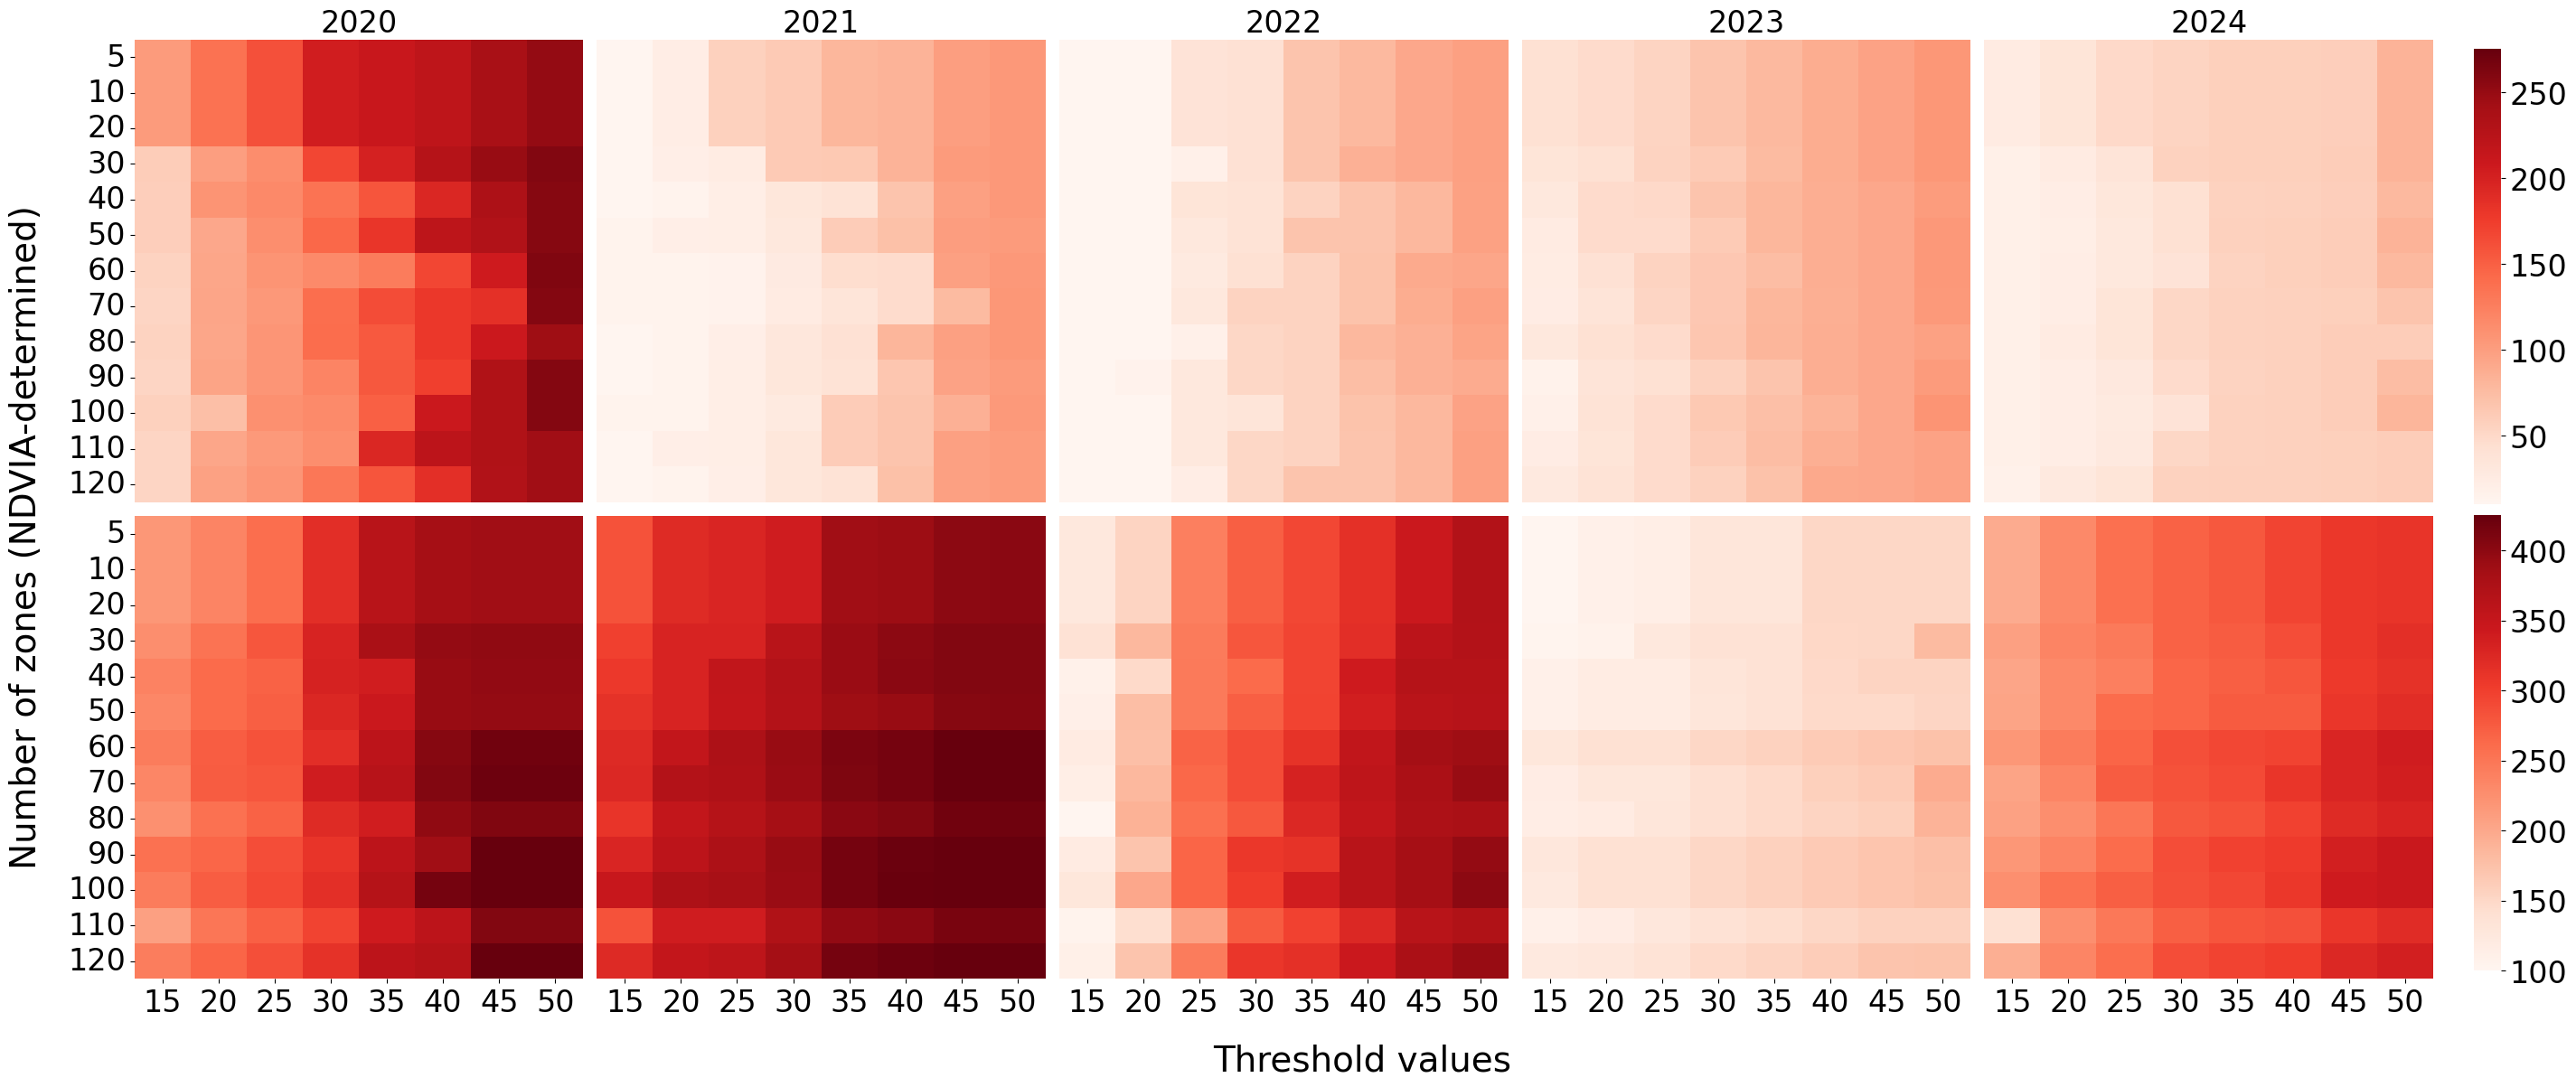

In [16]:
draw_heatmaps(count_files_list)

#### Multivariate regression for different inputs

Here we will visualise the model adjusted R² values, while other model parameters (such as RMSE and p-values) can be found in the model analysis folder.

In [18]:
imp_dir_NDVIA = os.path.join(csv_dir,'improvements','seasonal','NDVIA')
imp_dir_SWIA = os.path.join(csv_dir,'improvements','seasonal','SWIA')
imp_dir_all = os.path.join(csv_dir,'improvements','seasonal','all')
imp_dir_SWIANDVIA = os.path.join(csv_dir,'improvements','seasonal','SWIANDVIA')
imp_files_list = sorted([os.path.join(imp_dir_NDVIA, file) for file in os.listdir(imp_dir_NDVIA)]) + sorted([os.path.join(imp_dir_SWIA, file) for file in os.listdir(imp_dir_SWIA)]) + sorted([os.path.join(imp_dir_all, file) for file in os.listdir(imp_dir_all)]) + sorted([os.path.join(imp_dir_SWIANDVIA, file) for file in os.listdir(imp_dir_SWIANDVIA)])

/tmp/ipykernel_1702298/3455740520.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, .9, 1])


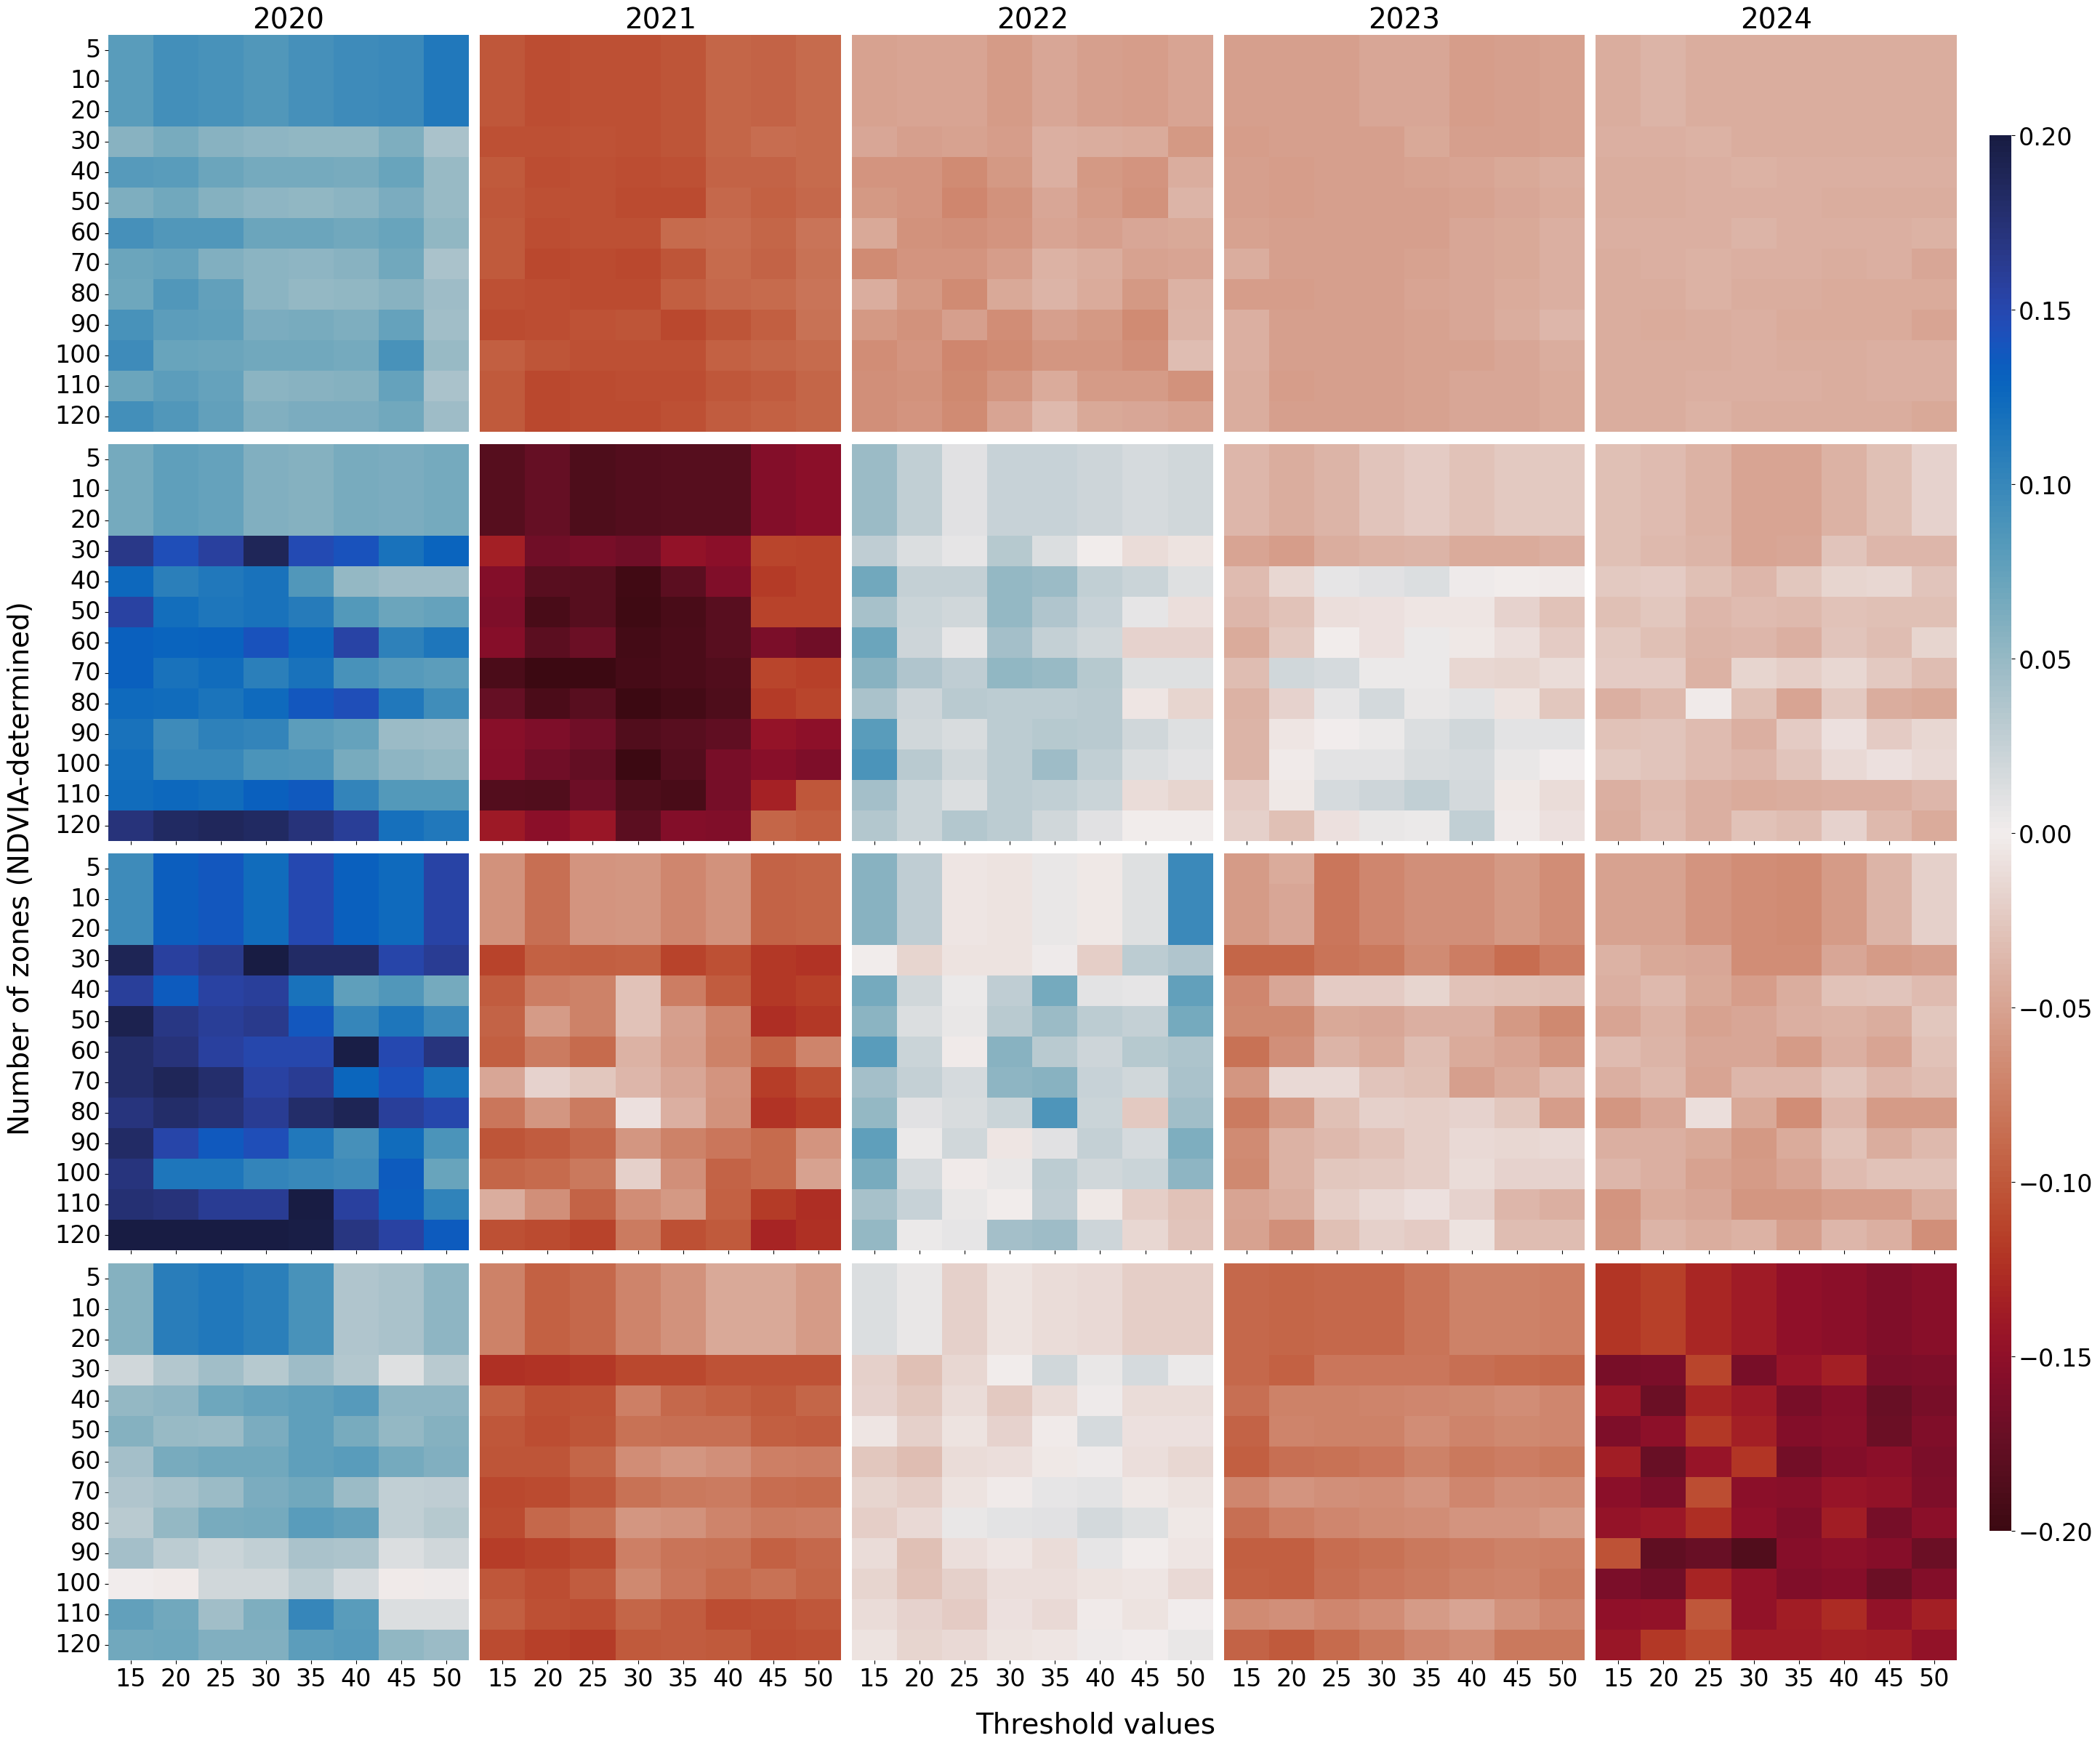

In [21]:
draw_improvement_heatmaps(imp_files_list)

And now we will visualise the same image with anomaly value statistics calculated over two phenological stages (vegetative/maturity) rather than over the entire growing season.

In [23]:
imp_dir_NDVIA = os.path.join(csv_dir,'improvements','phenological','NDVIA')
imp_dir_SWIA = os.path.join(csv_dir,'improvements','phenological','SWIA')
imp_dir_all = os.path.join(csv_dir,'improvements','phenological','all')
imp_dir_SWIANDVIA = os.path.join(csv_dir,'improvements','phenological','SWIANDVIA')
imp_files_list_p = sorted([os.path.join(imp_dir_NDVIA, file) for file in os.listdir(imp_dir_NDVIA)]) + sorted([os.path.join(imp_dir_SWIA, file) for file in os.listdir(imp_dir_SWIA)]) + sorted([os.path.join(imp_dir_all, file) for file in os.listdir(imp_dir_all)]) + sorted([os.path.join(imp_dir_SWIANDVIA, file) for file in os.listdir(imp_dir_SWIANDVIA)])

/tmp/ipykernel_1702298/3455740520.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, .9, 1])


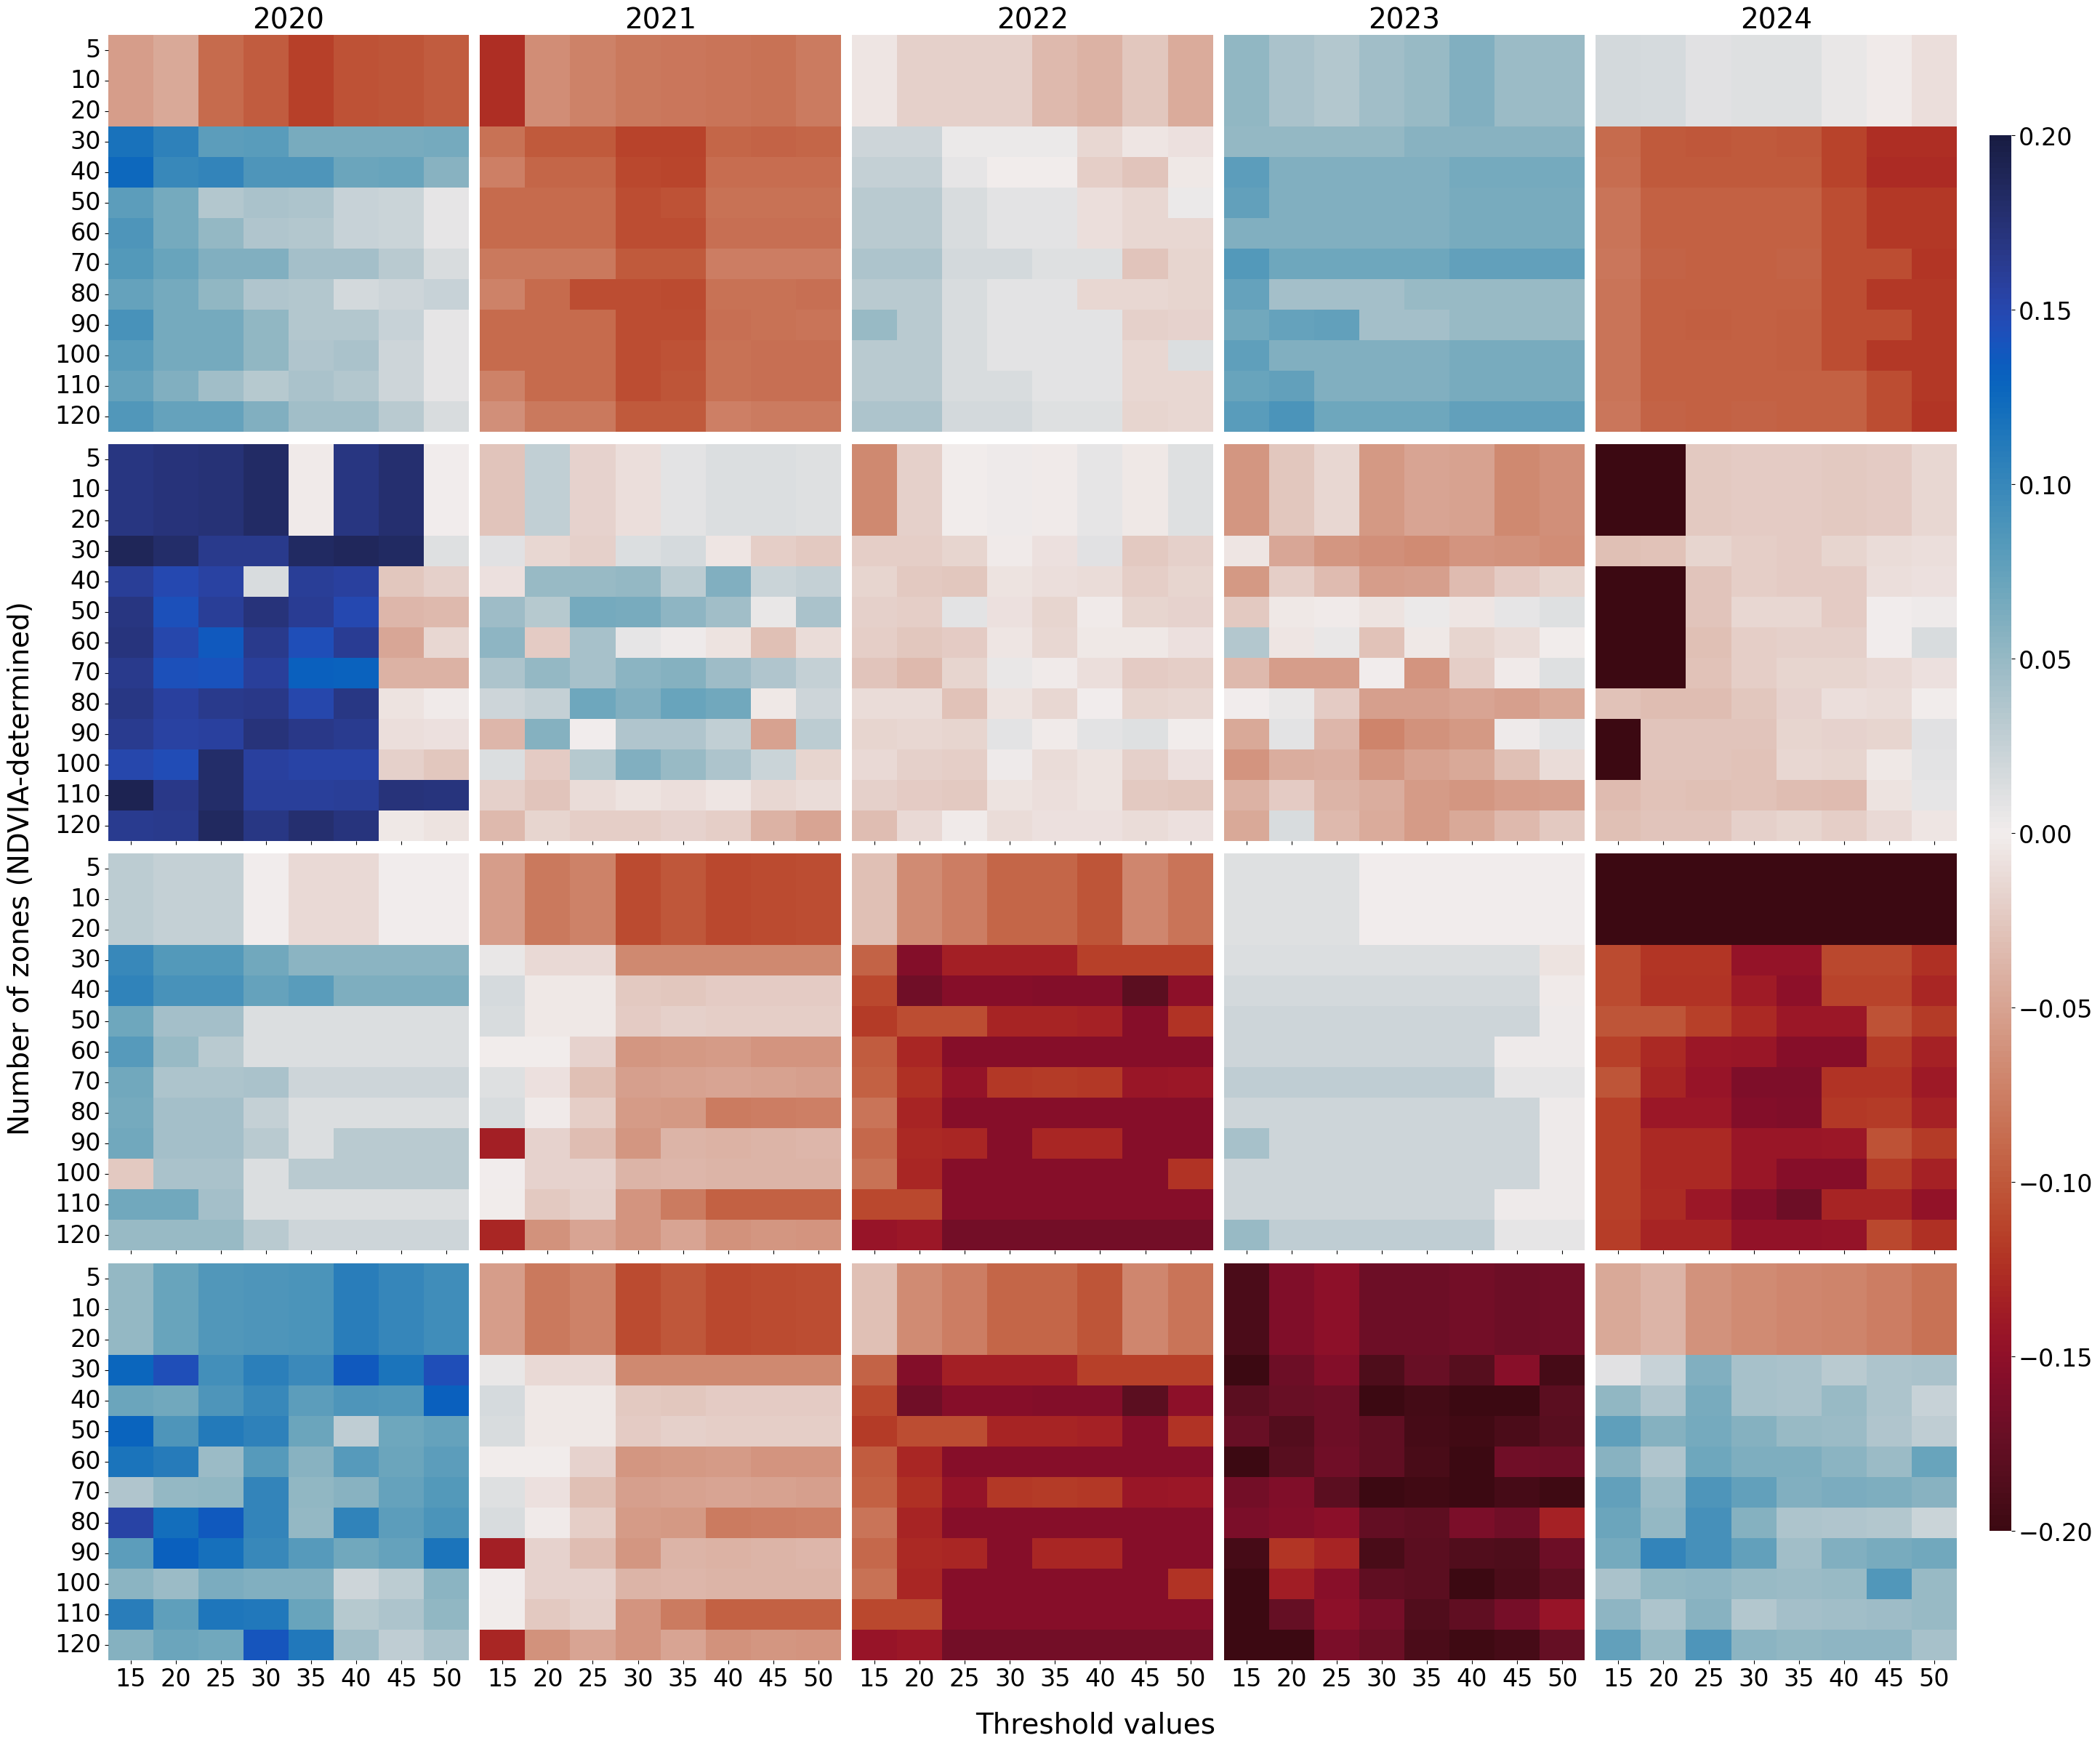

In [24]:
draw_improvement_heatmaps(imp_files_list_p)

Next, we will summarise RMSE values per model and per year from the csv files that were output during model calculations.

In [25]:
mse_NDVIA = os.path.join(csv_dir,'MSE','seasonal','NDVIA')
mse_SWIA = os.path.join(csv_dir,'MSE','seasonal','SWIA')
mse_all = os.path.join(csv_dir,'MSE','seasonal','all')
mse_SWIANDVIA = os.path.join(csv_dir,'MSE','seasonal','SWIANDVIA')
mse_p_NDVIA = os.path.join(csv_dir,'MSE','phenological','NDVIA')
mse_p_SWIA = os.path.join(csv_dir,'MSE','phenological','SWIA')
mse_p_all = os.path.join(csv_dir,'MSE','phenological','all')
mse_p_SWIANDVIA = os.path.join(csv_dir,'MSE','phenological','SWIANDVIA')
mse_files_list = sorted([os.path.join(mse_NDVIA, file) for file in os.listdir(mse_NDVIA)]) + sorted([os.path.join(mse_SWIA, file) for file in os.listdir(mse_SWIA)]) + sorted([os.path.join(mse_all, file) for file in os.listdir(mse_all)])  + sorted([os.path.join(mse_SWIANDVIA, file) for file in os.listdir(mse_SWIANDVIA)])
mse_p_files_list = sorted([os.path.join(mse_p_NDVIA, file) for file in os.listdir(mse_p_NDVIA)]) + sorted([os.path.join(mse_p_SWIA, file) for file in os.listdir(mse_p_SWIA)]) + sorted([os.path.join(mse_p_all, file) for file in os.listdir(mse_p_all)])  + sorted([os.path.join(mse_p_SWIANDVIA, file) for file in os.listdir(mse_p_SWIANDVIA)]) 

rmse_vals, rmse_df = calculate_rmse(mse_files_list, mse_p_files_list)

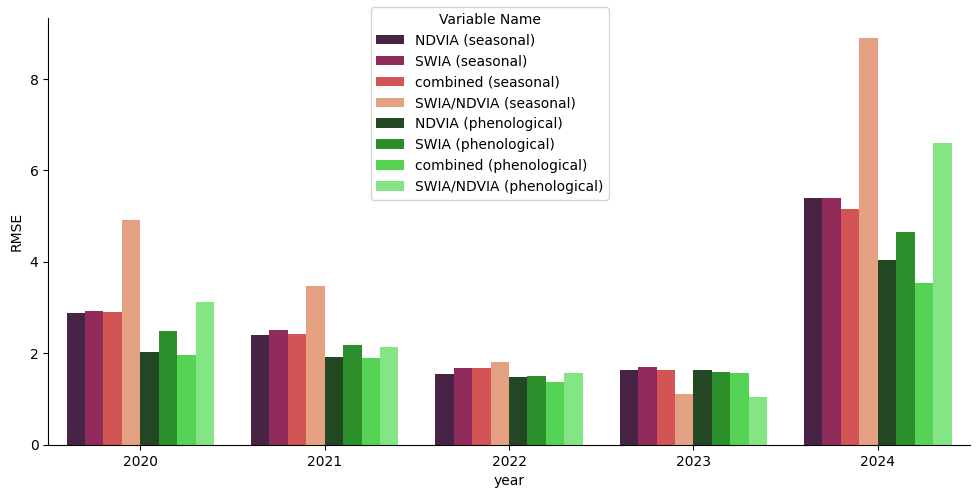

In [27]:
draw_rmse_barplot(rmse_vals)

## Spatial analysis

Finally, let's take a look at the generated results from a spatial perspective. This will demonstrate the different patterns in the anomaly variables for different states, allowing us to look at specific drought events in each state and how they were represented by meteorological variables, farmer reporting, and anomaly variables. We will by default use the anomaly variables from the calculation with 70 zones and a 20% upper threshold, but this setting can be changed by modifying the _num_zones_ and _u_thresh_ variables. Furthermore, the state of interest can be selected by modifying the numerical value of the _state_ variable. 

In [28]:
num_zones = 70
u_thresh = 20
states = ['NIGER', 'NASARAWA', 'OGUN', 'EBONYI']
state = states[2] 

print(f'Extracting data for {state} state, using anomaly variables from calculation with {num_zones} zones and {u_thresh}% upper threshold.')

Extracting data for OGUN state, using anomaly variables from calculation with 70 zones and 20% upper threshold.


In [35]:
plots_state, years_list, grouped, transplant_dates, harvest_dates, pan_dict, flo_dict, NDVIA_mean, SWIA_mean, drought_df = extract_data_for_graphs(rice_plots, main_dir, num_zones, u_thresh, state)

Filtering plot data by state.
Extracting index values per plot location.
Extracting anomaly values per plot location.
Getting seasonal dates for state.


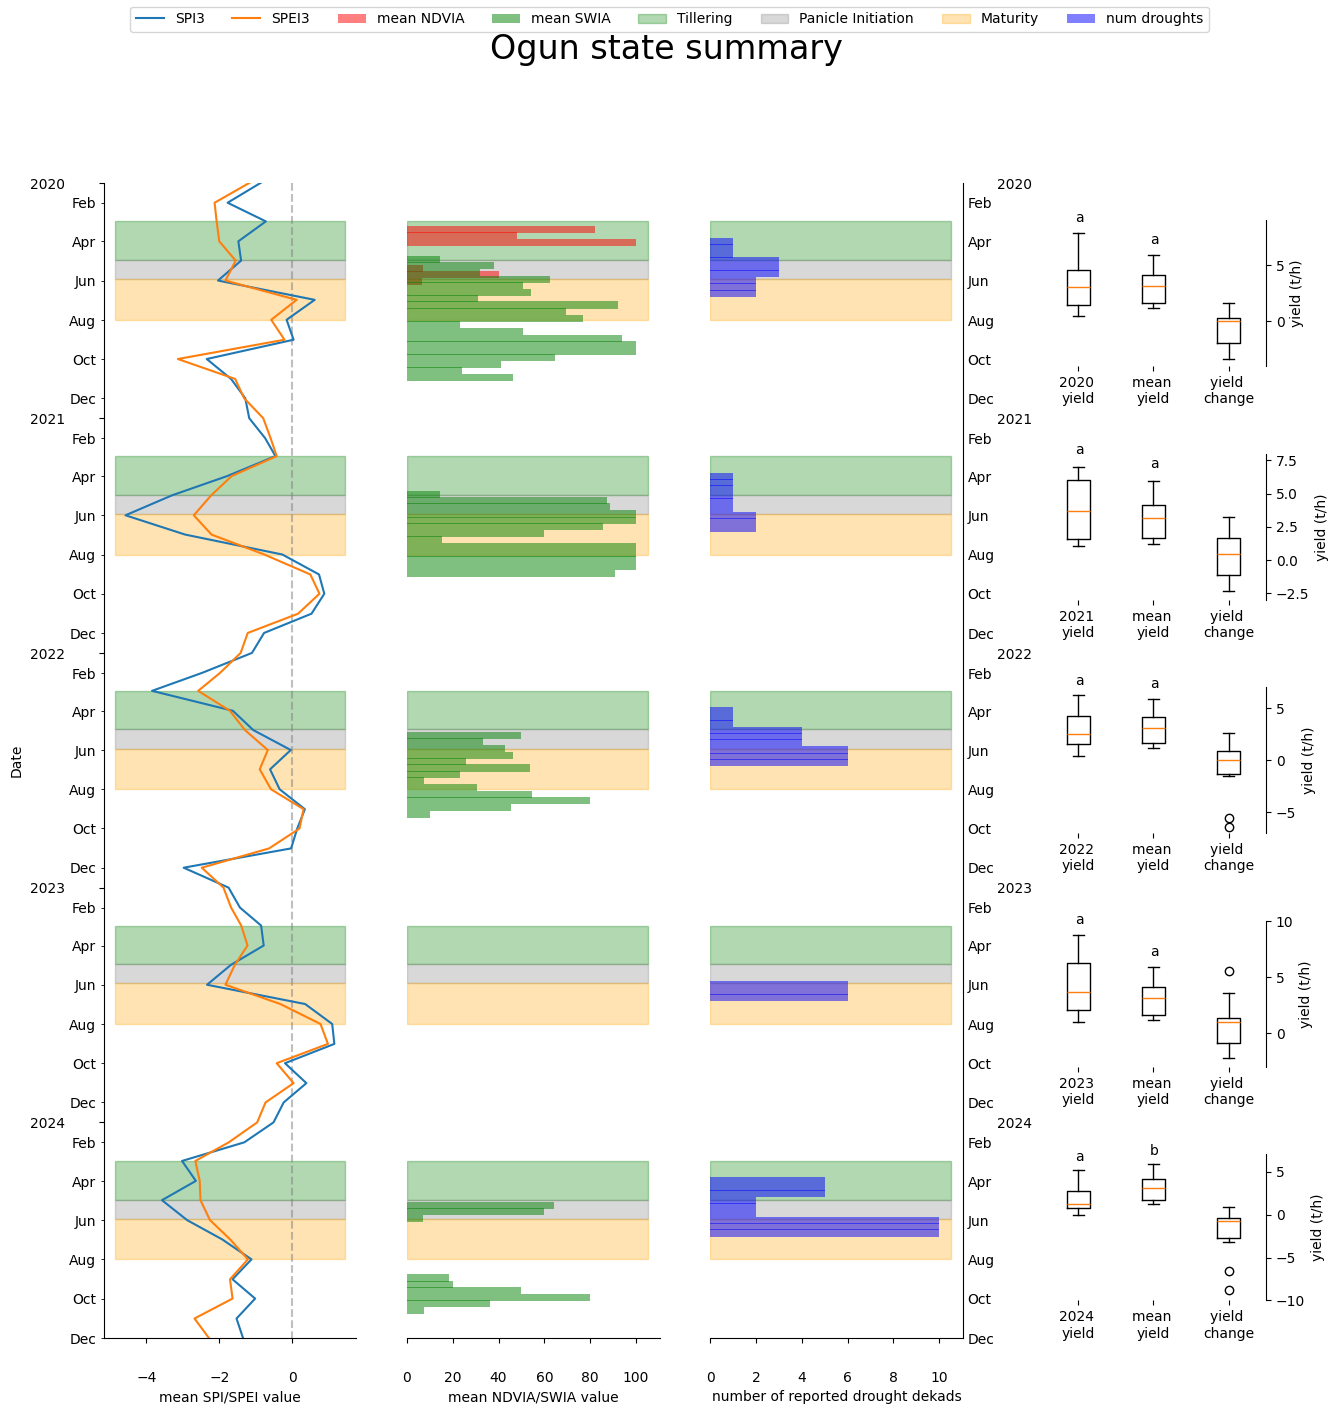

In [36]:
draw_state_figs(state, plots_state, years_list, grouped, transplant_dates, harvest_dates, pan_dict, flo_dict, NDVIA_mean, SWIA_mean, drought_df)